# Dog Breeds Dataset — EDA

---
## 1. Setup the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ── Plotting defaults ──
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 12
plt.rcParams['axes.titleweight']  = 'normal'

---
## 2. Setting Directory Paths 

In [2]:
# ── Paths ──
BASE_DIR = Path('/Users/sa02/class-projects/Capstone-Project/dog-breed-classification/Data/archive') 
CSV_PATH = '/Users/sa02/class-projects/Capstone-Project/dog-breed-classification/Data/dogs.csv'

---
## 3. Load & inspect the CSV file

In [3]:
df_dogs = pd.read_csv(CSV_PATH)

In [4]:
df_dogs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9346 entries, 0 to 9345
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   filepaths  9346 non-null   object
 1   labels     9346 non-null   object
 2   data set   9346 non-null   object
dtypes: object(3)
memory usage: 219.2+ KB


In [5]:
df_dogs.columns = df_dogs.columns.str.strip()
df_dogs['full_path']   = df_dogs['filepaths'].apply(lambda p: BASE_DIR / p.strip())
df_dogs['file_exists'] = df_dogs['full_path'].apply(lambda p: p.exists())

print(f'Rows loaded   : {len(df_dogs):,}')
print(f'Columns       : {list(df_dogs.columns)}')
print(f'Unique breeds : {df_dogs["labels"].nunique()}')
print(f'Null values   : {df_dogs.isnull().sum().sum()}')
print(f'Files found   : {df_dogs["file_exists"].sum():,} / {len(df_dogs):,}')
print()
print(df_dogs['data set'].value_counts().rename('count').to_frame())
df_dogs.head()

Rows loaded   : 9,346
Columns       : ['filepaths', 'labels', 'data set', 'full_path', 'file_exists']
Unique breeds : 71
Null values   : 0
Files found   : 9,346 / 9,346

          count
data set       
train      7946
test        700
valid       700


,filepaths,labels,data set,full_path,file_exists
0,train/Afghan/001.jpg,Afghan,train,/Users/sa02/class-projects/Capstone-Project/do...,True
1,train/Afghan/002.jpg,Afghan,train,/Users/sa02/class-projects/Capstone-Project/do...,True
2,train/Afghan/003.jpg,Afghan,train,/Users/sa02/class-projects/Capstone-Project/do...,True
3,train/Afghan/004.jpg,Afghan,train,/Users/sa02/class-projects/Capstone-Project/do...,True
4,train/Afghan/005.jpg,Afghan,train,/Users/sa02/class-projects/Capstone-Project/do...,True


- The CSV loads in with 9,346 records across 71 breeds, already split into train (7,946), validation (700), and test (700). The `file_exists` column is a quick sanity check, if any number comes back lower than the total row count, it means some files in the CSV aren't actually on disk, whether they got moved, renamed, or just didn't extract properly from the zip.

- No null values in the dataset, no imputations needed.

- One thing worth flagging: the dataset shows 71 unique breeds, but the original Kaggle page lists 70. That's a one-breed discrepancy that needs a closer look, could be a duplicate entry under a slightly different name, a labeling inconsistency, or a breed that got added without the page being updated. Either way, it's worth digging into before training.

---
## 4. Checking Unique Dog Breeds

In [7]:
print(df_dogs['labels'].unique())

['Afghan' 'African Wild Dog' 'Airedale' 'American Hairless'
 'American Spaniel' 'Basenji' 'Basset' 'Beagle' 'Bearded Collie'
 'Bermaise' 'Bichon Frise' 'Blenheim' 'Bloodhound' 'Bluetick'
 'Border Collie' 'Borzoi' 'Boston Terrier' 'Boxer' 'Bull Mastiff'
 'Bull Terrier' 'Bulldog' 'Cairn' 'Chihuahua' 'Chinese Crested' 'Chow'
 'Clumber' 'Cockapoo' 'Cocker' 'Collie' 'Corgi' 'Coyote' 'Dalmation'
 'Dhole' 'Dingo' 'Doberman' 'Elk Hound' 'French Bulldog' 'German Sheperd'
 'Golden Retriever' 'Great Dane' 'Great Perenees' 'Greyhound'
 'Groenendael' 'Irish Spaniel' 'Irish Wolfhound' 'Japanese Spaniel'
 'Komondor' 'Labradoodle' 'Labrador' 'Lhasa' 'Malinois' 'Maltese'
 'Mex Hairless' 'Newfoundland' 'Pekinese' 'Pit Bull' 'Pomeranian' 'Poodle'
 'Pug' 'Rhodesian' 'Rottweiler' 'Saint Bernard' 'Schnauzer'
 'Scotch Terrier' 'Shar_Pei' 'Shiba Inu' 'Shih-Tzu' 'Siberian Husky'
 'Vizsla' 'Yorkie' 'American  Spaniel']


- Here shows there are two entries for American Spaniel in the dataset. One is spelled correctly and the other has a double space: 'American  Spaniel'. Pandas treats these as two separate breeds, which is why the count showed 71 instead of Kaggle's 70. Stripping the extra whitespace fixes both problems at once.

In [8]:
df_dogs['labels'] = df_dogs['labels'].str.strip().str.replace(r'\s+', ' ', regex=True)

---
## 5. Class Distribution

In [10]:
# Count per breed × split
split_counts = df_dogs.groupby(['labels', 'data set']).size().unstack(fill_value=0)

# Ensure all three splits are present as columns
for col in ['train', 'valid', 'test']:
    if col not in split_counts.columns:
        split_counts[col] = 0

split_counts['total'] = split_counts.sum(axis=1)
split_counts = split_counts.sort_values('train', ascending=False)

print(f'Breeds: {len(split_counts)}')
print(f'\nTrain set stats:')
print(f'  Min  : {split_counts["train"].min()}  ({split_counts["train"].idxmin()})')
print(f'  Max  : {split_counts["train"].max()}  ({split_counts["train"].idxmax()})')
print(f'  Mean : {split_counts["train"].mean():.1f}')
print(f'  Std  : {split_counts["train"].std():.1f}')
print()
split_counts[['train', 'valid', 'test', 'total']].head(10)

Breeds: 70

Train set stats:
  Min  : 65  (American Hairless)
  Max  : 198  (Shih-Tzu)
  Mean : 113.5
  Std  : 24.7



data set,train,valid,test,total
labels,,,,
Shih-Tzu,198,10,10,218
Lhasa,187,10,10,207
Labrador,161,10,10,181
Basset,159,10,10,179
Scotch Terrier,150,10,10,170
Pomeranian,149,10,10,169
Pug,148,10,10,168
Bloodhound,147,10,10,167
Boxer,134,10,10,154


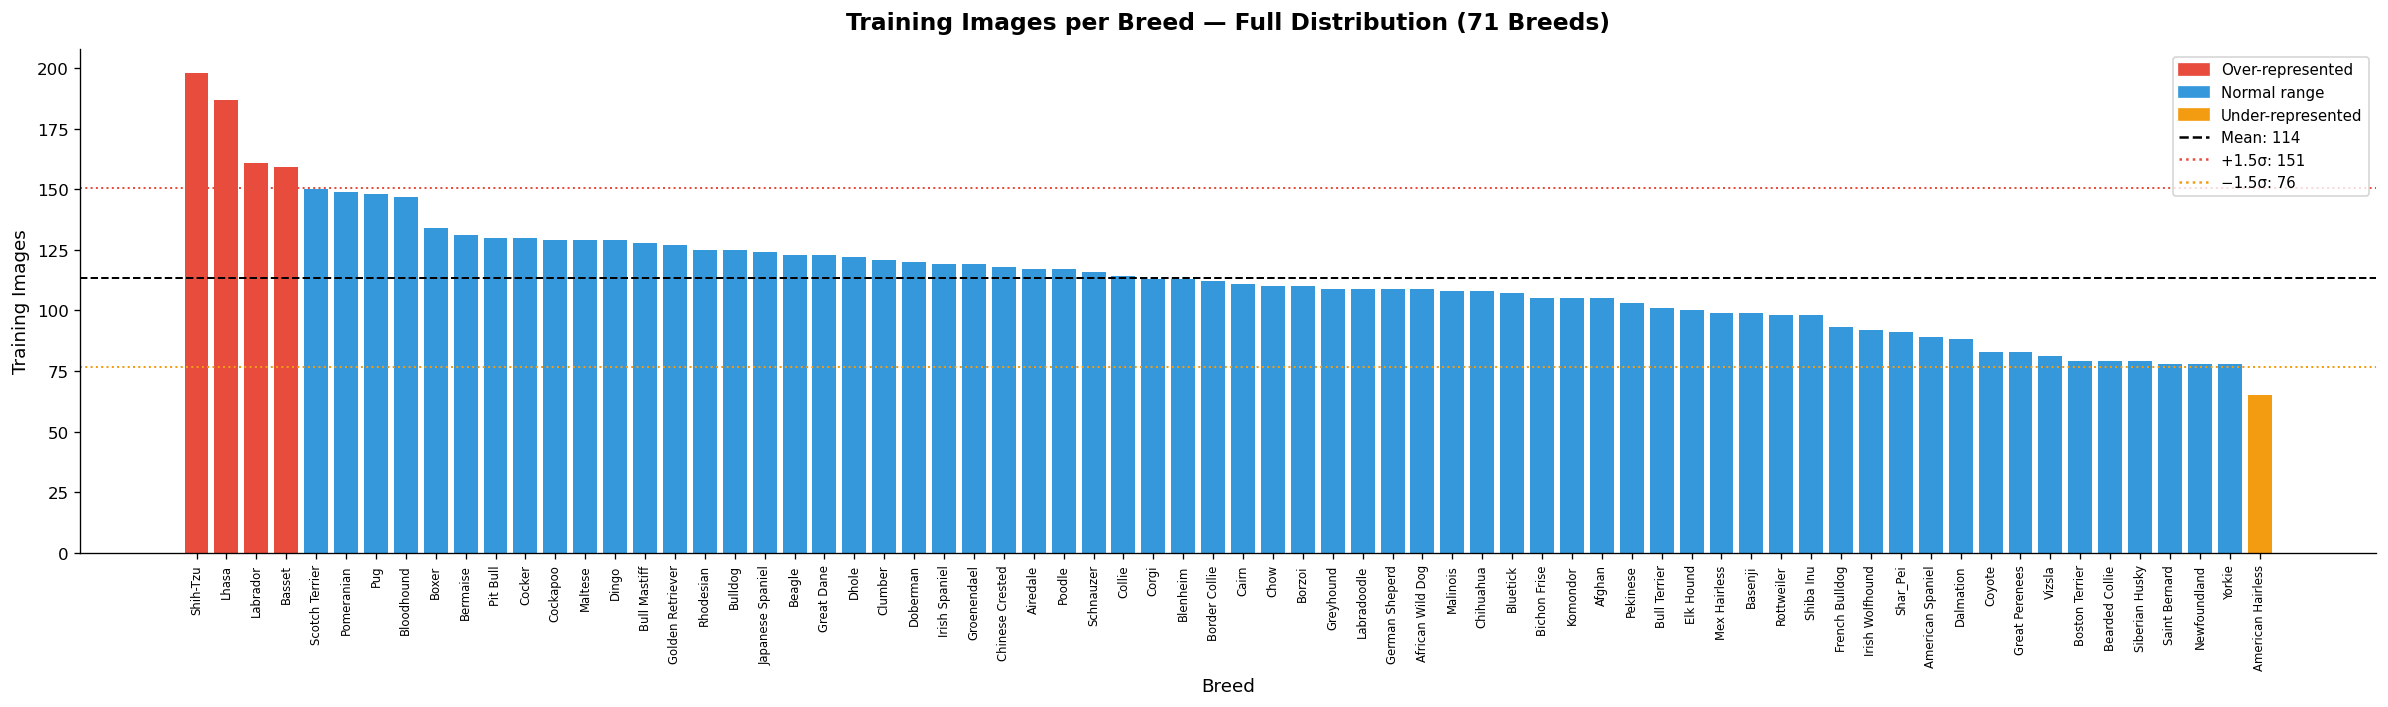

Over-represented breeds  (> 151 train imgs): 4
Under-represented breeds (< 76 train imgs): 1


In [11]:
# ── Full class distribution bar chart (sorted by train count) ──
mean_train = split_counts['train'].mean()
std_train  = split_counts['train'].std()
high_thresh = mean_train + 1.5 * std_train
low_thresh  = mean_train - 1.5 * std_train

bar_colors = []
for breed in split_counts.index:
    c = split_counts.loc[breed, 'train']
    if c > high_thresh:
        bar_colors.append('#e74c3c')   # red = over-represented
    elif c < low_thresh:
        bar_colors.append('#f39c12')   # orange = under-represented
    else:
        bar_colors.append('#3498db')   # blue = normal

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(split_counts.index, split_counts['train'], color=bar_colors,
       edgecolor='none', width=0.8)

ax.axhline(mean_train,  color='black',  linestyle='--', linewidth=1.2,
           label=f'Mean: {mean_train:.0f}')
ax.axhline(high_thresh, color='#e74c3c', linestyle=':', linewidth=1.2,
           label=f'+1.5σ: {high_thresh:.0f}')
ax.axhline(low_thresh,  color='#f39c12', linestyle=':', linewidth=1.2,
           label=f'−1.5σ: {low_thresh:.0f}')

patch_over  = mpatches.Patch(color='#e74c3c', label='Over-represented')
patch_norm  = mpatches.Patch(color='#3498db', label='Normal range')
patch_under = mpatches.Patch(color='#f39c12', label='Under-represented')
ax.legend(handles=[patch_over, patch_norm, patch_under,
                   plt.Line2D([0],[0], color='black', linestyle='--', label=f'Mean: {mean_train:.0f}'),
                   plt.Line2D([0],[0], color='#e74c3c', linestyle=':', label=f'+1.5σ: {high_thresh:.0f}'),
                   plt.Line2D([0],[0], color='#f39c12', linestyle=':', label=f'−1.5σ: {low_thresh:.0f}')],
          fontsize=9, loc='upper right')

ax.set_title('Training Images per Breed — Full Distribution (71 Breeds)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Breed', fontsize=11)
ax.set_ylabel('Training Images', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

over_rep  = split_counts[split_counts['train'] > high_thresh]
under_rep = split_counts[split_counts['train'] < low_thresh]
print(f'Over-represented breeds  (> {high_thresh:.0f} train imgs): {len(over_rep)}')
print(f'Under-represented breeds (< {low_thresh:.0f} train imgs): {len(under_rep)}')


- The chart shows the training image count for each breed, sorted from highest to lowest, with color coding based on how far each breed sits from the mean (114 images). The majority of breeds fall comfortably in the normal range (blue), meaning the dataset is reasonably balanced overall. However, a few outliers are worth noting — Shih-Tzu, Lhasa, Labrador, and Basset are flagged as over-represented (red), each exceeding the +1.5σ threshold of 151 images, with Shih-Tzu leading at 198. On the other end, American Hairless is the only breed that dipped below the −1.5σ threshold of 76, landing at 65 training images. While the imbalance isn't severe, these outliers on both ends could influence model performance and are worth addressing in Sprint 2 through class weighting or targeted augmentation.

---
## 6. Corrupted / missing file check

Document any images that fail to load, are unusually small (likely blank or placeholder), or cannot be verified.

In [13]:
# ── Missing files ────────────────────────────────────────────────
n_missing = (~df_dogs['file_exists']).sum()
print(f'Files expected : {len(df_dogs):,}')
print(f'Files found    : {df_dogs["file_exists"].sum():,}')
print(f'Files missing  : {n_missing:,}')

if n_missing > 0:
    print('\nSample of missing paths:')
    print(df_dogs[~df_dogs['file_exists']]['filepaths'].head(10).tolist())
    print('→ Update BASE_DIR in Section 1 to the folder containing train/valid/test.')
else:
    print('✅  All files present')

Files expected : 9,346
Files found    : 9,346
Files missing  : 0
✅  All files present


In [15]:
if not df_dogs['file_exists'].any():
    print('⚠️  No images found on disk. Update BASE_DIR at the top of Section 1.')
else:
    MIN_PIXELS = 32   # images smaller than 32×32 are flagged as suspiciously small

    corrupted  = []   # fails to open / verify
    too_small  = []   # opens but below MIN_PIXELS threshold

    valid_paths = df_dogs[df_dogs['file_exists']]
    print(f'Checking {len(valid_paths):,} images...')

    for _, row in valid_paths.iterrows():
        try:
            img = Image.open(row['full_path'])
            img.verify()              # header-level check (fast)
            img = Image.open(row['full_path'])  # re-open after verify
            w, h = img.size
            if w < MIN_PIXELS or h < MIN_PIXELS:
                too_small.append({'filepath': row['filepaths'],
                                  'width': w, 'height': h,
                                  'label': row['labels'],
                                  'split': row['data set']})
        except Exception as e:
            corrupted.append({'filepath': row['filepaths'],
                              'error': str(e),
                              'label': row['labels'],
                              'split': row['data set']})

    print(f'\nCorrupted files  : {len(corrupted)}')
    print(f'Suspiciously small (< {MIN_PIXELS}px): {len(too_small)}')

    if corrupted:
        print('\nCorrupted file list:')
        display(pd.DataFrame(corrupted))
    else:
        print('✅  No corrupted images detected')

    if too_small:
        print('\nSuspiciously small images:')
        display(pd.DataFrame(too_small))
    else:
        print(f'✅  No images below {MIN_PIXELS}×{MIN_PIXELS}px threshold')

Checking 9,346 images...

Corrupted files  : 0
Suspiciously small (< 32px): 0
✅  No corrupted images detected
✅  No images below 32×32px threshold


---
## Summary & Conclusions

### Dataset Quality
The dataset loaded cleanly with 9,346 images across 70 breeds (after label cleaning), split into train (7,946), validation (700), and test (700). There were no null values, no missing files, no corrupted images, and no suspiciously small images detected. From a file integrity standpoint, the dataset is production-ready with not much cleanup required.

### Label Issue — American Spaniel Double Space
One data quality issue was caught early: the dataset initially showed 71 breeds instead of Kaggle's listed 70. The cause was a duplicate entry — `'American Spaniel'` and `'American  Spaniel'` (double space) were being treated as two separate breeds by pandas. Stripping the extra whitespace resolved this, bringing the count back down to 70 and correctly consolidating all American Spaniel records under one label.

### Class Distribution
The dataset is reasonably balanced overall, with most breeds sitting close to the mean of 114 training images. That said, a few outliers were flagged using the ±1.5σ threshold. Shih-Tzu, Lhasa, Labrador, and Basset are over-represented — each exceeding 151 images, with Shih-Tzu leading at 198. On the other end, American Hairless is the only under-represented breed at 65 training images. While the imbalance isn't severe, these outliers could skew model predictions toward majority classes if left unaddressed.